# Display Test Accuracy

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from plots_utils.quanti import refine_results, plot_mean_seeds_var_over_training, plot_final_best_test_acc, plot_final_best_worst_test_acc

import os

In [2]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["42", "78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gp-35-tcsu-10ft gp-50-tcsu-10ft gp-35-tusu-10ft gp-50-tusu-10ft gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results = load_experiment_results(config)

refined_res, best_worst_res = refine_results(raw_results)

Processing experiments:   0%|          | 0/5 [00:00<?, ?it/s]2024-11-06 16:36:20.842749: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-06 16:36:20.854936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-06 16:36:20.869265: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-06 16:36:20.873460: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-06

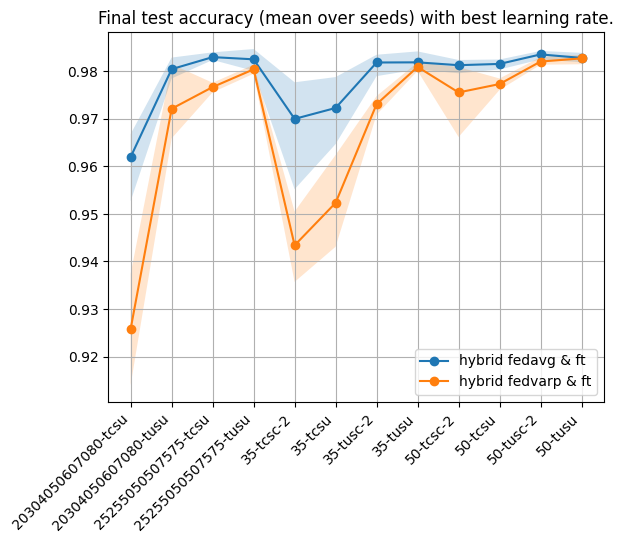

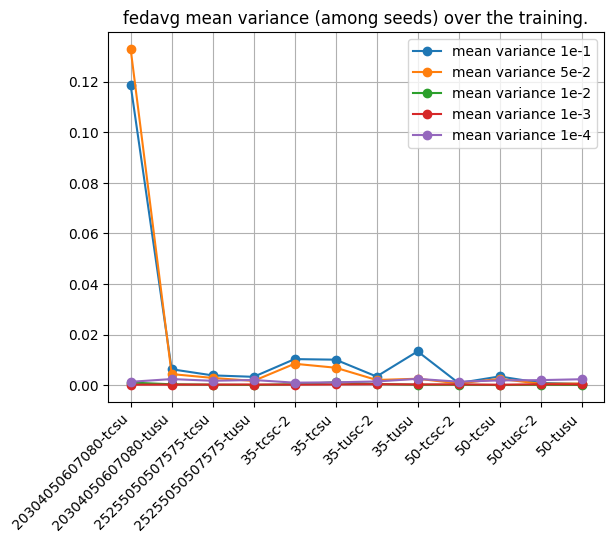

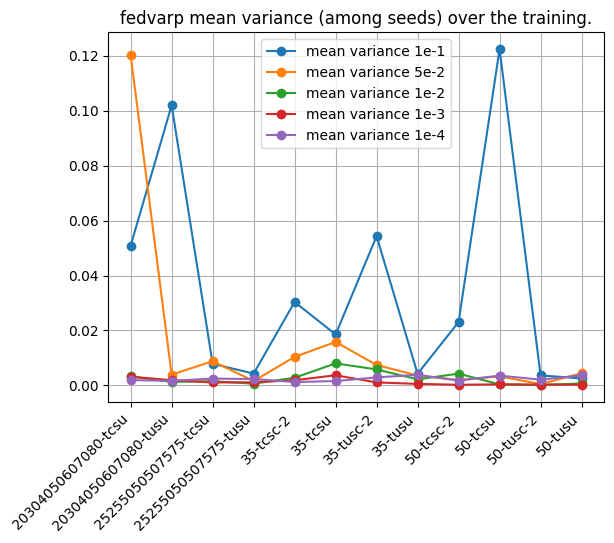

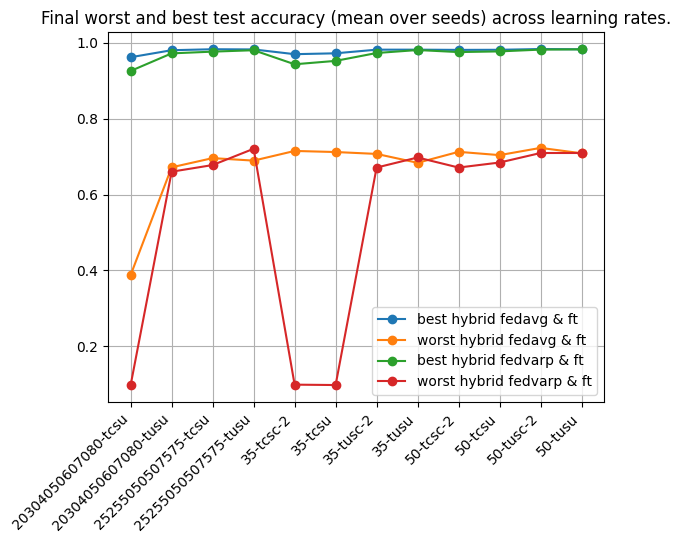

In [3]:
plot_final_best_test_acc(best_worst_res)
plot_mean_seeds_var_over_training(refined_res)
plot_final_best_worst_test_acc(best_worst_res)